# 🚇 Prédiction de l'affluence RATP — Paris 75

**Objectif :** Construire un modèle ML capable de prédire le nombre de voyageurs journaliers dans les transports parisiens en fonction de la météo, du calendrier et des événements sociaux (grèves, vacances, jours fériés).

---
| Étape | Contenu |
|---|---|
| 0 | Configuration & imports |
| 1 | Chargement des données transports |
| 2 | Chargement de la météo régionale |
| 3 | Fusion & construction des features |
| 4 | Statistiques descriptives |
| 5 | Entraînement (coupure chronologique + TimeSeriesSplit) |
| 6 | Évaluation & visualisations |
| 7 | Sauvegarde du modèle |
| 8 | Simulateur d'affluence |

## ⚙️ Cellule 0 — Configuration & Imports

In [17]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Paramètres globaux ────────────────────────────────────────────────────────
DEPARTEMENT_CIBLE  = 75
DEPARTEMENTS_IDF   = [75, 77, 78, 91, 92, 93, 94, 95]
DATE_DEBUT         = '2019-07-01'
DATE_FIN           = '2019-12-31'
MODELE_PATH        = 'modele_ratp.joblib'
TEST_SIZE          = 0.20   # 20% les plus récents pour le test
N_FOLDS_CV         = 5

COLONNES_FEATURES = [
    'Température', 'Pluie_mm', 'Pluie_Heures', 'Humidité', 'Vent', 'Visibilité',
    'Jour_Semaine', 'Est_Weekend', 'Mois', 'Greve', 'Jour_Ferie', 'Vacances_Scolaires'
]

print('✅ Imports et configuration OK')

✅ Imports et configuration OK


### Calendrier — Jours fériés & vacances scolaires Zone C

In [18]:
# ── Jours fériés (2017-2019) ──────────────────────────────────────────────────
JOURS_FERIES = pd.to_datetime([
    '2019-01-01','2019-04-22','2019-05-01','2019-05-08',
    '2019-05-30','2019-06-10','2019-07-14','2019-08-15',
    '2019-11-01','2019-11-11','2019-12-25',
    '2018-01-01','2018-04-02','2018-05-01','2018-05-08',
    '2018-05-10','2018-05-21','2018-07-14','2018-08-15',
    '2018-11-01','2018-11-11','2018-12-25',
    '2017-01-01','2017-04-17','2017-05-01','2017-05-08',
    '2017-05-25','2017-06-05','2017-07-14','2017-08-15',
    '2017-11-01','2017-11-11','2017-12-25',
])

# ── Vacances scolaires Zone C ─────────────────────────────────────────────────
VACANCES = {
    'ete_2019':       ('2019-07-01', '2019-09-01'),
    'toussaint_2019': ('2019-10-19', '2019-11-03'),
    'noel_2019':      ('2019-12-21', '2019-12-31'),
    'ete_2018':       ('2018-07-07', '2018-09-03'),
    'toussaint_2018': ('2018-10-20', '2018-11-04'),
    'noel_2018':      ('2018-12-22', '2018-12-31'),
    'ete_2017':       ('2017-07-08', '2017-09-04'),
    'toussaint_2017': ('2017-10-21', '2017-11-05'),
    'noel_2017':      ('2017-12-23', '2017-12-31'),
}

toutes_vacances = pd.DatetimeIndex([])
for debut, fin in VACANCES.values():
    toutes_vacances = toutes_vacances.union(pd.date_range(start=debut, end=fin))

print(f'✅ {len(JOURS_FERIES)} jours fériés  |  {len(toutes_vacances)} jours de vacances indexés')

✅ 33 jours fériés  |  259 jours de vacances indexés


## 📦 Cellule 1 — Chargement des données Transports

In [19]:
print('Chargement des validations RATP...')

df_transports = pd.read_csv('Travel_titles_with_departments.csv')
df_transports = df_transports[df_transports['DEPARTEMENT'] == DEPARTEMENT_CIBLE].copy()
df_transports['DATE'] = pd.to_datetime(df_transports['DATE'])
df_transports = df_transports.groupby('DATE', as_index=False)['NB_VALID'].sum()

print(f'✅ {len(df_transports)} jours chargés')
print(f'   Période : {df_transports["DATE"].min().date()} → {df_transports["DATE"].max().date()}')
df_transports.tail(3)

Chargement des validations RATP...
✅ 184 jours chargés
   Période : 2019-07-01 → 2019-12-31


,DATE,NB_VALID
181,2019-12-29,207227
182,2019-12-30,557503
183,2019-12-31,421396


## 🌦️ Cellule 2 — Chargement de la météo régionale Île-de-France

In [20]:
print('Chargement des fichiers météo (lecture par chunks pour économiser la RAM)...')

# Colonnes utiles uniquement — réduit la RAM de ~60%
COLONNES_METEO = ['AAAAMMJJHH', 'NUM_POSTE', 'T', 'RR1', 'U', 'FF', 'VV']
CHUNK_SIZE     = 50_000

liste_df = []
for dep in DEPARTEMENTS_IDF:
    nom_fichier = f'H_{dep}_2010-2019.csv.gz'
    try:
        chunks_utiles = []
        for chunk in pd.read_csv(
            nom_fichier,
            compression='gzip',
            sep=';',
            usecols=lambda c: c in COLONNES_METEO,
            chunksize=CHUNK_SIZE,
            low_memory=False
        ):
            # Filtre directement dans le chunk — on ne garde que la période utile
            chunk['DATE_FULL'] = pd.to_datetime(chunk['AAAAMMJJHH'], format='%Y%m%d%H', errors='coerce')
            chunk = chunk[
                (chunk['DATE_FULL'] >= DATE_DEBUT) &
                (chunk['DATE_FULL'] <= DATE_FIN)
            ]
            if not chunk.empty:
                chunks_utiles.append(chunk)
        if chunks_utiles:
            liste_df.append(pd.concat(chunks_utiles, ignore_index=True))
            print(f'   ✓ {nom_fichier}')
        else:
            print(f'   ~ {nom_fichier} (aucune donnée sur la période)')
    except FileNotFoundError:
        print(f'   ✗ Manquant : {nom_fichier}')

if not liste_df:
    raise FileNotFoundError('Aucun fichier météo trouvé !')

print(f'\n✅ {len(liste_df)} fichier(s) chargé(s)')

Chargement des fichiers météo (lecture par chunks pour économiser la RAM)...
   ✓ H_75_2010-2019.csv.gz
   ✓ H_77_2010-2019.csv.gz
   ✓ H_78_2010-2019.csv.gz
   ✓ H_91_2010-2019.csv.gz
   ✓ H_92_2010-2019.csv.gz
   ~ H_93_2010-2019.csv.gz (aucune donnée sur la période)
   ✓ H_94_2010-2019.csv.gz
   ✓ H_95_2010-2019.csv.gz

✅ 7 fichier(s) chargé(s)


In [21]:
# Fusion de tous les départements — déjà filtrés sur la période dans la cellule précédente
df_filtre = pd.concat(liste_df, ignore_index=True)
df_filtre = df_filtre.dropna(subset=['DATE_FULL'])
df_filtre['JOUR'] = df_filtre['DATE_FULL'].dt.normalize()

# Étape 1 : agrégation par station
df_stations = df_filtre.groupby(['JOUR', 'NUM_POSTE']).agg(
    T                    = ('T',   'mean'),
    Pluie_mm_station     = ('RR1', 'sum'),
    Pluie_Heures_station = ('RR1', lambda x: (x > 0).sum()),
    U                    = ('U',   'mean'),
    FF                   = ('FF',  'mean'),
    VV                   = ('VV',  'mean')
).reset_index()

# Étape 2 : moyenne régionale
df_meteo = df_stations.groupby('JOUR').agg(
    T            = ('T',                    'mean'),
    Pluie_mm     = ('Pluie_mm_station',     'mean'),
    Pluie_Heures = ('Pluie_Heures_station', 'mean'),
    Humidité     = ('U',                    'mean'),
    Vent         = ('FF',                   'mean'),
    Visibilité   = ('VV',                   'mean')
).reset_index()

# Conversion Kelvin → Celsius si nécessaire
df_meteo['Température'] = df_meteo['T'].apply(
    lambda x: round(x - 273.15, 2) if pd.notna(x) and x > 100 else round(x, 2)
)
df_meteo = df_meteo.drop(columns=['T']).rename(columns={'JOUR': 'DATE'}).round(2)

print(f'✅ {len(df_meteo)} jours météo calculés')
df_meteo.tail(3)

✅ 184 jours météo calculés


,DATE,Pluie_mm,Pluie_Heures,Humidité,Vent,Visibilité,Température
181,2019-12-29,0.09,0.41,87.46,1.90,9317.29,1.66
182,2019-12-30,0.07,0.37,85.13,1.29,9140.90,1.70
183,2019-12-31,0.00,0.00,94.84,1.29,4214.09,-0.66


## 🔧 Cellule 3 — Fusion & Construction des features

In [22]:
df_ml = pd.merge(df_transports, df_meteo, on='DATE', how='inner')
df_ml = df_ml.sort_values('DATE').reset_index(drop=True)

# Variables temporelles
df_ml['Jour_Semaine']      = df_ml['DATE'].dt.dayofweek
df_ml['Est_Weekend']       = (df_ml['Jour_Semaine'] >= 5).astype(int)
df_ml['Mois']              = df_ml['DATE'].dt.month

# Événements
df_ml['Greve']             = (df_ml['DATE'] >= '2019-12-05').astype(int)
df_ml['Jour_Ferie']        = df_ml['DATE'].isin(JOURS_FERIES).astype(int)
df_ml['Vacances_Scolaires']= df_ml['DATE'].isin(toutes_vacances).astype(int)

print(f'✅ Dataset final : {len(df_ml)} lignes × {df_ml.shape[1]} colonnes')
df_ml[COLONNES_FEATURES + ['NB_VALID']].head(3)

✅ Dataset final : 184 lignes × 14 colonnes


,Température,Pluie_mm,Pluie_Heures,Humidité,Vent,Visibilité,Jour_Semaine,Est_Weekend,Mois,Greve,Jour_Ferie,Vacances_Scolaires,NB_VALID
0,19.22,0.19,0.55,65.52,2.98,30305.30,0,0,7,0,0,1,2756977
1,18.85,0.02,0.08,60.60,3.25,28625.65,1,0,7,0,0,1,3024789
2,19.64,0.00,0.00,55.26,4.48,28706.99,2,0,7,0,0,1,3038948


## 📊 Cellule 4 — Statistiques descriptives

STATISTIQUES DU JEU DE DONNÉES
  Jours analysés       : 184
  Période              : 2019-07-01 → 2019-12-31
  Trafic moyen/jour    :    2,233,494 voyageurs
  Trafic max (pic)     :    3,743,515 voyageurs
  Trafic min (creux)   :      171,281 voyageurs
  Jours de grève       : 27
  Jours fériés         : 5
  Jours de vacances    : 90


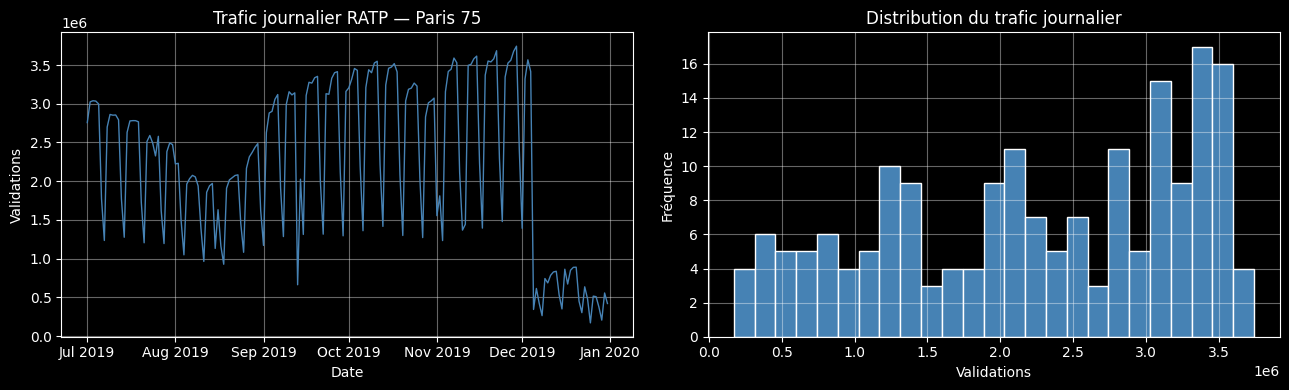

In [23]:
print('=' * 55)
print('STATISTIQUES DU JEU DE DONNÉES')
print('=' * 55)
print(f'  Jours analysés       : {len(df_ml)}')
print(f'  Période              : {df_ml["DATE"].min().date()} → {df_ml["DATE"].max().date()}')
print(f'  Trafic moyen/jour    : {int(df_ml["NB_VALID"].mean()):>12,} voyageurs')
print(f'  Trafic max (pic)     : {int(df_ml["NB_VALID"].max()):>12,} voyageurs')
print(f'  Trafic min (creux)   : {int(df_ml["NB_VALID"].min()):>12,} voyageurs')
print(f'  Jours de grève       : {df_ml["Greve"].sum()}')
print(f'  Jours fériés         : {df_ml["Jour_Ferie"].sum()}')
print(f'  Jours de vacances    : {df_ml["Vacances_Scolaires"].sum()}')
print('=' * 55)

# Distribution du trafic
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_ml['DATE'], df_ml['NB_VALID'], color='steelblue', linewidth=1)
axes[0].set_title('Trafic journalier RATP — Paris 75')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Validations')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].grid(alpha=0.4)

axes[1].hist(df_ml['NB_VALID'], bins=25, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution du trafic journalier')
axes[1].set_xlabel('Validations')
axes[1].set_ylabel('Fréquence')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

## 🤖 Cellule 5 — Entraînement du modèle

In [24]:
# ── Split stratifié sur la grève ──────────────────────────────────────────────
# Problème du split chronologique pur : toute la grève (déc 2019) tombe
# dans le test set → le modèle ne voit jamais la grève pendant l'entraînement.
#
# Solution : on sépare les jours de grève des jours normaux, puis on
# constitue train/test en prenant 80% de chaque groupe séparément.
# Résultat : la grève est représentée dans les deux sets.

from sklearn.model_selection import train_test_split

X = df_ml[COLONNES_FEATURES]
y = df_ml['NB_VALID']

idx_greve   = df_ml[df_ml['Greve'] == 1].index
idx_normal  = df_ml[df_ml['Greve'] == 0].index

# 80/20 sur chaque groupe indépendamment
train_normal, test_normal = train_test_split(idx_normal, test_size=TEST_SIZE, random_state=42)
train_greve,  test_greve  = train_test_split(idx_greve,  test_size=TEST_SIZE, random_state=42)

train_idx = train_normal.tolist() + train_greve.tolist()
test_idx  = test_normal.tolist()  + test_greve.tolist()

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

# split_idx fictif pour compatibilité avec les graphiques
split_idx = int(len(df_ml) * (1 - TEST_SIZE))

print(f'Train : {len(X_train)} jours  |  Test : {len(X_test)} jours')
print(f'Jours de grève → train : {df_ml.loc[train_idx, "Greve"].sum()}  /  test : {df_ml.loc[test_idx, "Greve"].sum()}')

Train : 146 jours  |  Test : 38 jours
Jours de grève → train : 21  /  test : 6


In [25]:
# ── Validation croisée temporelle (TimeSeriesSplit) ───────────────────────────
tscv   = TimeSeriesSplit(n_splits=N_FOLDS_CV)
modele = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

scores_cv = cross_val_score(modele, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)

print(f'TimeSeriesSplit ({N_FOLDS_CV} folds) :')
for i, s in enumerate(scores_cv, 1):
    print(f'  Fold {i} → R² = {s:.3f}')
print(f'  Moyenne : {scores_cv.mean():.3f}  ±  {scores_cv.std():.3f}')

TimeSeriesSplit (5 folds) :
  Fold 1 → R² = 0.630
  Fold 2 → R² = 0.856
  Fold 3 → R² = 0.884
  Fold 4 → R² = 0.643
  Fold 5 → R² = -5.151
  Moyenne : -0.428  ±  2.364


In [26]:
# ── Entraînement final sur tout le train set ──────────────────────────────────
modele.fit(X_train, y_train)
predictions = modele.predict(X_test)

mae  = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions) * 100
r2   = r2_score(y_test, predictions)

print('\n' + '='*50)
print('RÉSULTATS SUR LE JEU DE TEST')
print('='*50)
print(f'  MAE  (erreur absolue)  : {mae:>12,.0f} voyageurs/jour')
print(f'  MAPE (erreur relative) : {mape:>11.1f}%')
print(f'  R²                     : {r2:>12.3f} / 1.000')
print('='*50)


RÉSULTATS SUR LE JEU DE TEST
  MAE  (erreur absolue)  :      211,215 voyageurs/jour
  MAPE (erreur relative) :        13.6%
  R²                     :        0.865 / 1.000


## 📈 Cellule 6 — Évaluation & Visualisations

Calcul de la permutation importance (peut prendre quelques secondes)...


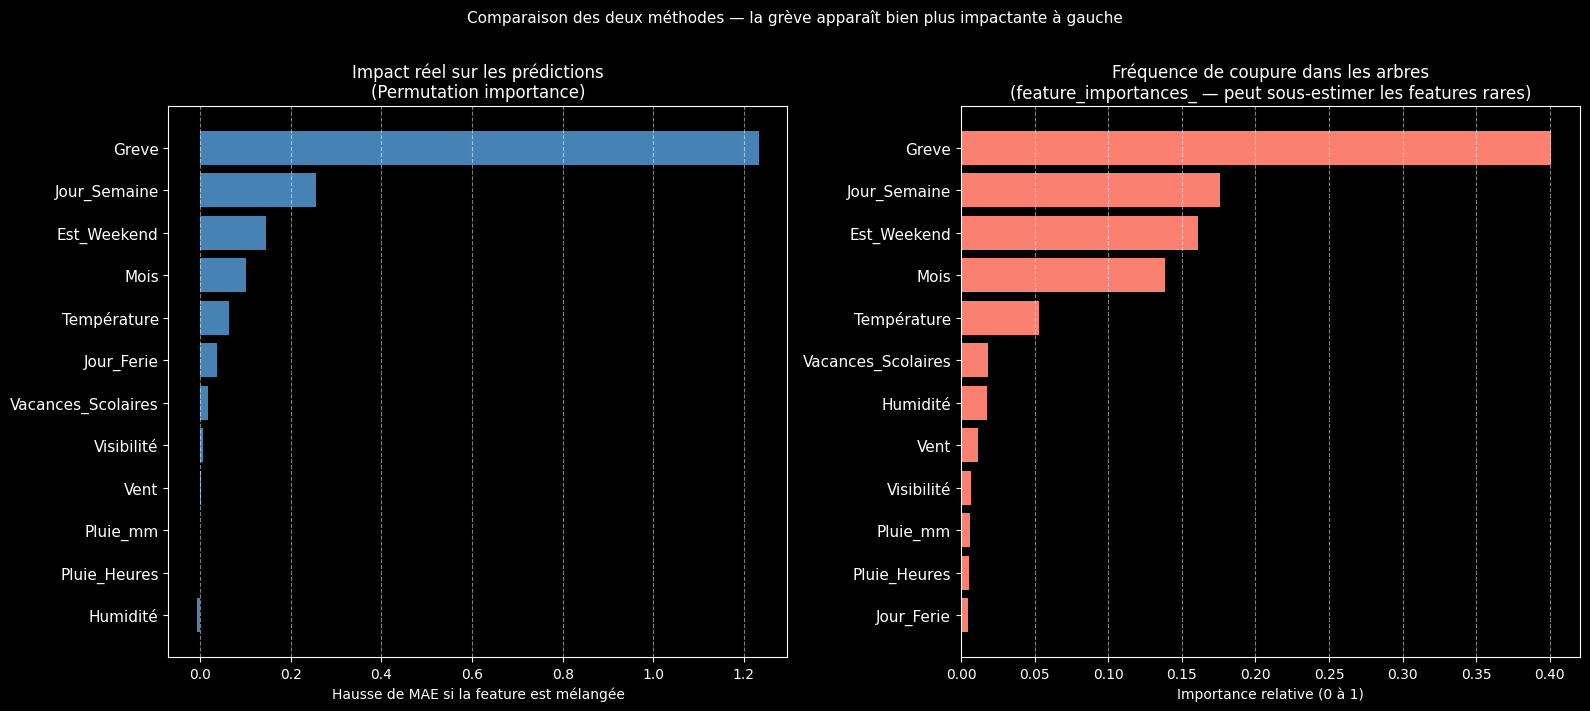

✅ Graphique sauvegardé → feature_importances.png


In [27]:
from sklearn.inspection import permutation_importance

# ── Permutation importance (mesure l'impact RÉEL sur les prédictions) ─────────
# Contrairement à feature_importances_, cette méthode mesure de combien
# l'erreur du modèle augmente quand on mélange aléatoirement une feature.
# Résultat : les features rares mais décisives (ex: Grève) sont correctement valorisées.
print('Calcul de la permutation importance (peut prendre quelques secondes)...')
perm = permutation_importance(modele, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

indices = np.argsort(perm.importances_mean)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : Permutation importance (correct)
axes[0].set_title('Impact réel sur les prédictions\n(Permutation importance)', fontsize=12)
axes[0].barh(range(len(indices)), perm.importances_mean[indices], color='steelblue', align='center')
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels([COLONNES_FEATURES[i] for i in indices], fontsize=11)
axes[0].set_xlabel('Hausse de MAE si la feature est mélangée')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Graphique 2 : Importance RF classique (fréquence de coupure)
importances_rf = modele.feature_importances_
indices_rf     = np.argsort(importances_rf)
axes[1].set_title('Fréquence de coupure dans les arbres\n(feature_importances_ — peut sous-estimer les features rares)', fontsize=12)
axes[1].barh(range(len(indices_rf)), importances_rf[indices_rf], color='salmon', align='center')
axes[1].set_yticks(range(len(indices_rf)))
axes[1].set_yticklabels([COLONNES_FEATURES[i] for i in indices_rf], fontsize=11)
axes[1].set_xlabel('Importance relative (0 à 1)')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Comparaison des deux méthodes — la grève apparaît bien plus impactante à gauche', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé → feature_importances.png')

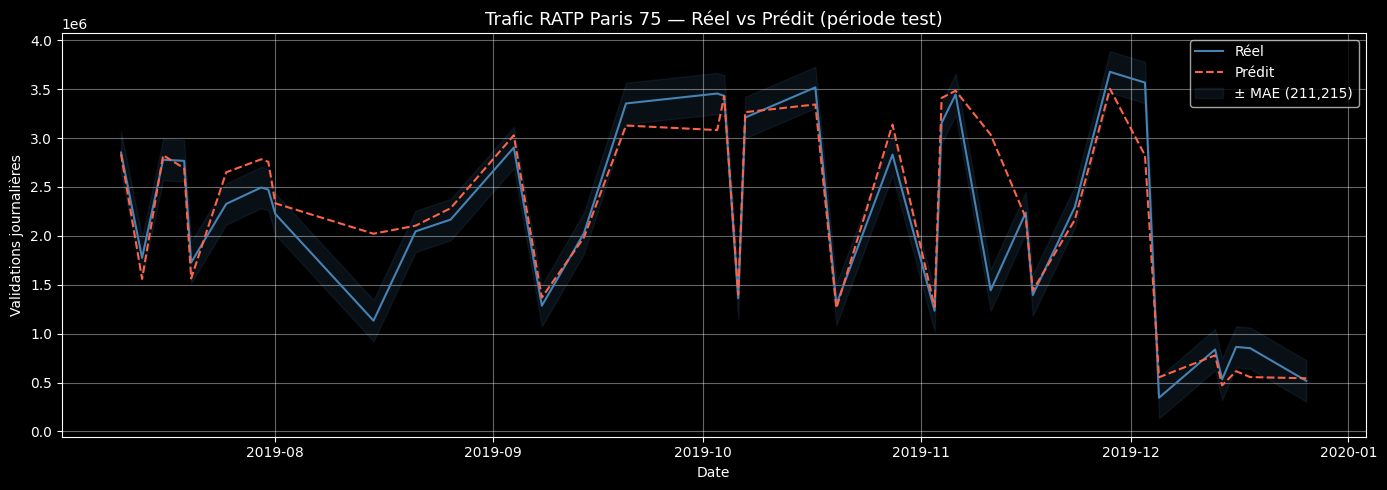

In [28]:
# ── Réel vs Prédit sur la période test ───────────────────────────────────────
dates_test = df_ml.loc[test_idx, 'DATE'].sort_values().values
y_test_sorted       = y_test.loc[df_ml.loc[test_idx, 'DATE'].sort_values().index]
predictions_sorted  = predictions[df_ml.loc[test_idx, 'DATE'].argsort()]

plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test_sorted.values,  label='Réel',  color='steelblue', linewidth=1.5)
plt.plot(dates_test, predictions_sorted,    label='Prédit', color='tomato',    linewidth=1.5, linestyle='--')
plt.fill_between(dates_test,
                 np.array(y_test_sorted.values) - mae,
                 np.array(y_test_sorted.values) + mae,
                 alpha=0.12, color='steelblue', label=f'± MAE ({mae:,.0f})')
plt.title('Trafic RATP Paris 75 — Réel vs Prédit (période test)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Validations journalières')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('predictions_vs_reel.png', dpi=150)
plt.show()

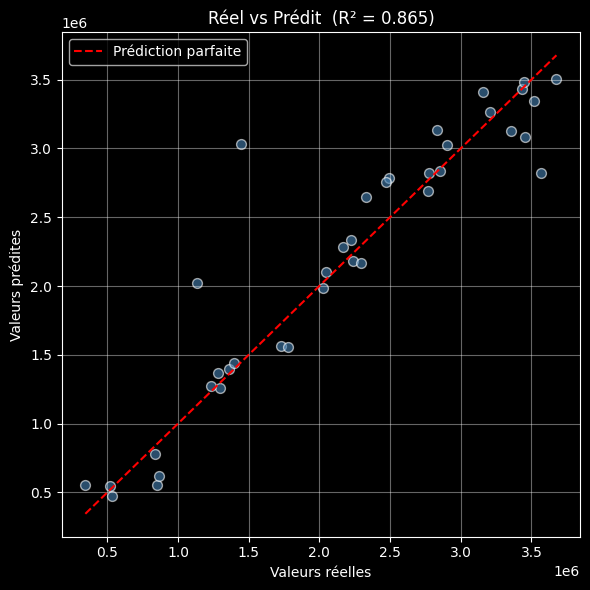

In [29]:
# ── Scatter : Réel vs Prédit ──────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue', edgecolors='white', s=50)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title(f'Réel vs Prédit  (R² = {r2:.3f})')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 💾 Cellule 7 — Sauvegarde & Rechargement du modèle

In [30]:
# ── Sauvegarde (modèle + colonnes ensemble) ───────────────────────────────────
payload = {'modele': modele, 'colonnes': COLONNES_FEATURES}
joblib.dump(payload, MODELE_PATH)
print(f'✅ Modèle sauvegardé → {MODELE_PATH}')

# ── Rechargement (utile pour un autre notebook ou une app) ───────────────────
payload_charge  = joblib.load(MODELE_PATH)
modele_charge   = payload_charge['modele']
colonnes_charge = payload_charge['colonnes']
print(f'✅ Modèle rechargé  → {len(colonnes_charge)} features : {colonnes_charge}')

✅ Modèle sauvegardé → modele_ratp.joblib
✅ Modèle rechargé  → 12 features : ['Température', 'Pluie_mm', 'Pluie_Heures', 'Humidité', 'Vent', 'Visibilité', 'Jour_Semaine', 'Est_Weekend', 'Mois', 'Greve', 'Jour_Ferie', 'Vacances_Scolaires']


## 🎮 Cellule 8 — Simulateur d'affluence

Modifie les paramètres dans la cellule suivante pour simuler n'importe quel scénario.

In [31]:
JOURS_MAP = {
    'Lundi':0, 'Mardi':1, 'Mercredi':2, 'Jeudi':3,
    'Vendredi':4, 'Samedi':5, 'Dimanche':6
}

def calculer_affluence(
    modele,
    colonnes,
    temp,
    pluie,
    greve,
    jour_ferie        = 0,
    vacances_scolaires= 0,
    jour_type         = 'Lundi',
    mois              = 12,
    vent              = 15.0,
    visibilite        = 15000.0,
    humidite          = None,     # auto-déduit si None
):
    """
    Prédit le nombre de voyageurs pour un scénario donné.
    L'humidité est déduite automatiquement si non fournie.
    """
    jour = jour_type.strip().capitalize()
    if jour not in JOURS_MAP:
        raise ValueError(f"Jour invalide : '{jour_type}'. Valides : {list(JOURS_MAP.keys())}")

    js       = JOURS_MAP[jour]
    h        = humidite if humidite is not None else (85.0 if pluie > 0 else 60.0)
    pluie_h  = 3.0 if pluie > 0 else 0.0

    entree = pd.DataFrame([{
        'Température':        temp,
        'Pluie_mm':           pluie,
        'Pluie_Heures':       pluie_h,
        'Humidité':           h,
        'Vent':               vent,
        'Visibilité':         visibilite,
        'Jour_Semaine':       js,
        'Est_Weekend':        int(js >= 5),
        'Mois':               mois,
        'Greve':              greve,
        'Jour_Ferie':         jour_ferie,
        'Vacances_Scolaires': vacances_scolaires,
    }])[colonnes]

    return int(modele.predict(entree)[0])

print('✅ Fonction calculer_affluence() prête')

✅ Fonction calculer_affluence() prête


In [32]:
# ── Scénarios de simulation ───────────────────────────────────────────────────
scenarios = [
    {'label': 'Lundi Novembre  (Normal)',         'temp':10, 'pluie':0,  'greve':0, 'jour_ferie':0, 'vacances_scolaires':0, 'jour_type':'Lundi',    'mois':11},
    {'label': 'Lundi Novembre  (Jour férié)',      'temp':10, 'pluie':0,  'greve':0, 'jour_ferie':1, 'vacances_scolaires':0, 'jour_type':'Lundi',    'mois':11},
    {'label': 'Lundi Novembre  (Vacances)',        'temp':10, 'pluie':0,  'greve':0, 'jour_ferie':0, 'vacances_scolaires':1, 'jour_type':'Lundi',    'mois':11},
    {'label': 'Lundi Novembre  (Grève)',           'temp':10, 'pluie':0,  'greve':1, 'jour_ferie':0, 'vacances_scolaires':0, 'jour_type':'Lundi',    'mois':11},
    {'label': 'Lundi Novembre  (Pluie 15 mm)',     'temp':10, 'pluie':15, 'greve':0, 'jour_ferie':0, 'vacances_scolaires':0, 'jour_type':'Lundi',    'mois':11},
    {'label': 'Samedi Juillet  (Été, beau temps)', 'temp':28, 'pluie':0,  'greve':0, 'jour_ferie':0, 'vacances_scolaires':1, 'jour_type':'Samedi',   'mois':7},
    {'label': 'Vendredi Décemb (Avant Noël)',      'temp':5,  'pluie':2,  'greve':0, 'jour_ferie':0, 'vacances_scolaires':0, 'jour_type':'Vendredi', 'mois':12},
]

print('=' * 57)
print('SIMULATEUR D\'AFFLUENCE RATP — PARIS 75')
print('=' * 57)

resultats = {}
for s in scenarios:
    kw = {k: v for k, v in s.items() if k != 'label'}
    n  = calculer_affluence(modele, COLONNES_FEATURES, **kw)
    resultats[s['label']] = n
    print(f"  {s['label']:<42} : {n:>12,} voyageurs")

ref = resultats['Lundi Novembre  (Normal)']
print('\n' + '-' * 57)
print('IMPACTS vs Lundi Normal :')
for label, val in resultats.items():
    if label != 'Lundi Novembre  (Normal)':
        delta = ((ref - val) / ref) * 100
        signe = '↓' if delta > 0 else '↑'
        print(f"  {label:<42} → {signe} {abs(delta):.1f}%")
print('=' * 57)

SIMULATEUR D'AFFLUENCE RATP — PARIS 75
  Lundi Novembre  (Normal)                   :    3,296,020 voyageurs
  Lundi Novembre  (Jour férié)               :    2,948,393 voyageurs
  Lundi Novembre  (Vacances)                 :    3,208,519 voyageurs
  Lundi Novembre  (Grève)                    :      921,376 voyageurs
  Lundi Novembre  (Pluie 15 mm)              :    3,337,037 voyageurs
  Samedi Juillet  (Été, beau temps)          :    1,541,048 voyageurs
  Vendredi Décemb (Avant Noël)               :    3,312,922 voyageurs

---------------------------------------------------------
IMPACTS vs Lundi Normal :
  Lundi Novembre  (Jour férié)               → ↓ 10.5%
  Lundi Novembre  (Vacances)                 → ↓ 2.7%
  Lundi Novembre  (Grève)                    → ↓ 72.0%
  Lundi Novembre  (Pluie 15 mm)              → ↑ 1.2%
  Samedi Juillet  (Été, beau temps)          → ↓ 53.2%
  Vendredi Décemb (Avant Noël)               → ↑ 0.5%
